In [55]:
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

# scipy
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# muutils
from muutils.dbg import dbg, dbg_tensor
import muutils.tensor_info
from muutils.tensor_info import array_summary

muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True

# attention-motifs

# pl.set_option('display.max_rows', 200)
# pl.set_option('display.max_columns', 200)

In [2]:
# DATA: pl.DataFrame = pl.DataFrame(jsonl_load("../data/scalar_features.jsonl"))

DATA: pl.DataFrame = pl.read_ndjson(Path("../data/scalar_features_fixed.jsonl"))

In [3]:
DATA.head()

feat.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.log.gram.col.beta_hist.hist.raw.linreg.r2,feat.log.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.diag.rms,feat.gram.col.beta_hist.hist.raw.variance,feat.markov_transition.time.L2_norm,feat.diag.entropy,feat.gram.row.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.mean,feat.gram.row.beta_hist.hist.raw.skewness,feat.gram.skew.beta_hist.hist.raw.energy,feat.log.gram.skew.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.mean,feat.markov_transition.time.skewness,feat.log.gram.skew.beta_hist.hist.raw.mean,feat.log.gram.skew.beta_hist.hist.raw.std,feat.diag.linreg.slope,feat.diag.kurtosis,feat.first_tok.L1_norm,feat.gram.row.beta_hist.hist.raw.L2_norm,feat.markov_transition.diff.kurtosis,feat.log.gram.row.beta_hist.hist.raw.entropy,feat.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.gram.skew.beta_hist.hist.raw.L2_norm,feat.log.gram.row.beta_hist.hist.raw.median,feat.diag.autocorr_lag1,feat.gram.col.beta_hist.hist.raw.median,feat.gram.row.beta_hist.hist.raw.energy,feat.first_tok.skewness,feat.log.gram.col.beta_hist.hist.raw.linreg.intercept,feat.first_tok.psd_total_power,feat.markov_transition.env.lower.slope,feat.markov_transition.env.lower.intercept,feat.gram.col.beta_hist.hist.raw.kurtosis,feat.diag.linreg.r2,feat.log.gram.row.beta_hist.hist.raw.energy,…,feat.gram.col.beta_hist.hist.raw.rms,feat.gram.col.beta_hist.hist.raw.psd_total_power,feat.gram.row.beta_hist.hist.raw.std,feat.first_tok.variance,feat.gram.skew.beta_hist.hist.raw.median,feat.first_tok.L2_norm,feat.markov_transition.time.entropy,feat.markov_transition.time.rms,feat.diag.L1_norm,feat.markov_transition.time.std,feat.markov_transition.diff.linreg.intercept,feat.gram.col.beta_hist.hist.raw.std,feat.log.gram.col.beta_hist.hist.raw.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.linreg.slope,feat.log.gram.skew.beta_hist.hist.raw.entropy,feat.log.gram.row.beta_hist.hist.raw.std,feat.log.gram.skew.beta_hist.hist.raw.variance,feat.log.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.log.gram.row.beta_hist.hist.raw.linreg.slope,feat.diag.variance,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.markov_transition.time.L1_norm,feat.log.gram.col.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.rms,feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.skew.beta_hist.hist.raw.std,feat.markov_transition.diff.std,feat.markov_transition.time.median,activation.cls,feat.first_tok.linreg.r2,feat.gram.col.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.entropy,feat.first_tok.entropy,feat.markov_transition.env.upper.slope,feat.markov_transition.diff.mean,feat.markov_transition.diff.rms,feat.markov_transition.env.lower.r2
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64
0.0,131.525631,0.144661,1.792928,0.236381,7541.80449,0.0,2.15858,20.142488,0.163203,1.094303,397792.161079,0.931865,35.058429,null,0.931865,3.058511,-0.001612,5.722651,0.076226,5.451335,108.008929,0.39979,121.245875,19.709615,0.0,0.158451,1.896931,30430.265188,3.412402,-0.292124,0.733353,-0.0,0.0,12.415323,0.104208,18.311236,…,94.085666,40381.852535,23.723699,0.028752,1.833027,0.017348,0.0,0.0,0.169934,0.0,0.034932,86.843563,0.878773,0.02949,0.200622,0.75046,9.354491,0.0,0.029276,0.027237,0.029031,0.0,0.164973,0.756456,55.760361,107.532616,0.094072,0.0,"""pythia-14m:L0:H0""",0.303453,39.319073,0.644974,1.140814,0.0,0.00885,0.094072,1.0
0.0,123.309449,0.109687,2.131102,0.377833,17436.341397,0.0,2.593486,29.286952,0.157499,4.415902,632693.457519,1.08779,34.15348,null,1.08779,3.023088,-0.00052,-0.29873,0.039348,13.658481,108.008929,0.200622,123.778461,24.856884,0.0,-0.096441,1.273686,191031.395499

In [11]:
# print unique values for columns which start with "activations"
print(f"{DATA['activation.model'].unique() = }")

DATA['activation.model'].unique() = shape: (6,)
Series: 'activation.model' [str]
[
	"pythia-1b"
	"gpt2-medium"
	"gemma-2b"
	"tiny-stories-1M"
	"gpt2-small"
	"pythia-14m"
]


In [5]:
DATA.describe()

statistic,feat.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.log.gram.col.beta_hist.hist.raw.linreg.r2,feat.log.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.diag.rms,feat.gram.col.beta_hist.hist.raw.variance,feat.markov_transition.time.L2_norm,feat.diag.entropy,feat.gram.row.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.mean,feat.gram.row.beta_hist.hist.raw.skewness,feat.gram.skew.beta_hist.hist.raw.energy,feat.log.gram.skew.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.mean,feat.markov_transition.time.skewness,feat.log.gram.skew.beta_hist.hist.raw.mean,feat.log.gram.skew.beta_hist.hist.raw.std,feat.diag.linreg.slope,feat.diag.kurtosis,feat.first_tok.L1_norm,feat.gram.row.beta_hist.hist.raw.L2_norm,feat.markov_transition.diff.kurtosis,feat.log.gram.row.beta_hist.hist.raw.entropy,feat.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.gram.skew.beta_hist.hist.raw.L2_norm,feat.log.gram.row.beta_hist.hist.raw.median,feat.diag.autocorr_lag1,feat.gram.col.beta_hist.hist.raw.median,feat.gram.row.beta_hist.hist.raw.energy,feat.first_tok.skewness,feat.log.gram.col.beta_hist.hist.raw.linreg.intercept,feat.first_tok.psd_total_power,feat.markov_transition.env.lower.slope,feat.markov_transition.env.lower.intercept,feat.gram.col.beta_hist.hist.raw.kurtosis,feat.diag.linreg.r2,…,feat.gram.col.beta_hist.hist.raw.rms,feat.gram.col.beta_hist.hist.raw.psd_total_power,feat.gram.row.beta_hist.hist.raw.std,feat.first_tok.variance,feat.gram.skew.beta_hist.hist.raw.median,feat.first_tok.L2_norm,feat.markov_transition.time.entropy,feat.markov_transition.time.rms,feat.diag.L1_norm,feat.markov_transition.time.std,feat.markov_transition.diff.linreg.intercept,feat.gram.col.beta_hist.hist.raw.std,feat.log.gram.col.beta_hist.hist.raw.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.linreg.slope,feat.log.gram.skew.beta_hist.hist.raw.entropy,feat.log.gram.row.beta_hist.hist.raw.std,feat.log.gram.skew.beta_hist.hist.raw.variance,feat.log.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.log.gram.row.beta_hist.hist.raw.linreg.slope,feat.diag.variance,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.markov_transition.time.L1_norm,feat.log.gram.col.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.rms,feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.skew.beta_hist.hist.raw.std,feat.markov_transition.diff.std,feat.markov_transition.time.median,activation.cls,feat.first_tok.linreg.r2,feat.gram.col.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.entropy,feat.first_tok.entropy,feat.markov_transition.env.upper.slope,feat.markov_transition.diff.mean,feat.markov_transition.diff.rms,feat.markov_transition.env.lower.r2
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,829.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,…,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,"""123872""",123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,123043.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

In [6]:
def nan_stats(df: pl.DataFrame) -> pl.DataFrame:
	return (
		df.null_count()
		.transpose(include_header=True, header_name="feature", column_names=["count"])
		.sort("count", descending=True)
	)


nan_stats(DATA)

feature,count
str,u32
"""feat.markov_transition.time.sk…",123043
"""feat.markov_transition.time.ku…",123043
"""feat.gram.skew.beta_hist.hist.…",0
"""feat.gram.col.beta_hist.hist.r…",0
"""feat.log.gram.col.beta_hist.hi…",0
…,…
"""feat.first_tok.entropy""",0
"""feat.markov_transition.env.upp…",0
"""feat.markov_transition.diff.me…",0


In [25]:
def filter_data(df: pl.DataFrame, remove_models: list[str]|None = None) -> pl.DataFrame:
	"remove cols 'feat.*' which are all nan or have variance 0, rows with the listed models"
	# remove all rows where "activation.model" is in remove_models
	df_models_dropped: pl.DataFrame
	if remove_models is not None:
		print(f"Removing {len(remove_models)} models")
		print(f"Models: {remove_models}")
		df_models_dropped = df.filter(~pl.col("activation.model").is_in(set(remove_models)))
		print(f"Removed {len(df) - len(df_models_dropped)}/{len(df)} rows")
	else:
		print("Not removing any models")
		df_models_dropped = df


	# remove cols whose names start with "feat." and they have 0 variance
	feat_cols: list[str] = [col for col in df.columns if col.startswith("feat.")]
	remove_cols: list[str] = []

	for col in feat_cols:
		# Calculate variance, handling potential NaN values
		var = df_models_dropped.select(pl.col(col).var()).item()
		# print(f"{col = }, {df[col].is_null().sum() = }")
		if var == 0 or df_models_dropped[col].is_null().sum() > 10:
			remove_cols.append(col)

	print(f"Removing {len(remove_cols)}/{len(feat_cols)} cols")
	dbg(remove_cols)
	for col in remove_cols:
		print(f"{col:<60} {array_summary(df_models_dropped[col].to_numpy())}")

	# remove cols that are all nan
	df_cols_dropped: pl.DataFrame = df_models_dropped.drop(remove_cols)

	return df_cols_dropped


# because those have nan
DATA_FILTERED: pl.DataFrame = filter_data(DATA, remove_models=["tiny-stories-1M", "pythia-14m"])
nan_stats(DATA_FILTERED)

Removing 2 models
Models: ['tiny-stories-1M', 'pythia-14m']
Removed 19456/123872 rows
Removing 37/176 cols
feat.gram.skew.beta_hist.hist.raw.zero_crossing_rate         μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.time.L2_norm                          μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.time.skewness                         🚨 all NaN shape=104416 dtype=float64
feat.log.gram.row.beta_hist.hist.raw.median                  μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.env.lower.slope                       μ=0.00 σ=0.00 x̃=0.00 R=[-0.00,-0.00] shape=104416 dtype=float64
feat.markov_transition.env.lower.intercept                   μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.diag.zero_crossing_rate                                 μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.time.linreg.intercept     

[ <ipykernel>:27 -> filter_data ] remove_cols = ['feat.gram.skew.beta_hist.hist.raw.zero_crossing_rate', 'feat.markov_transition.time.L2_norm', 'feat.markov_transition.time.skewness', 'feat.log.gram.row.beta_hist.hist.raw.median', 'feat.markov_transition.env.lower.slope', 'feat.markov_transition.env.lower.intercept', 'feat.diag.zero_crossing_rate', 'feat.markov_transition.time.linreg.intercept', 'feat.markov_transition.diff.autocorr_lag1', 'feat.gram.col.beta_hist.hist.raw.zero_crossing_rate', 'feat.markov_transition.time.mean', 'feat.markov_transition.diff.median', 'feat.log.gram.col.beta_hist.hist.raw.zero_crossing_rate', 'feat.markov_transition.env.upper.r2', 'feat.markov_transition.time.linreg.r2', 'feat.log.gram.row.beta_hist.hist.raw.zero_crossing_rate', 'feat.markov_transition.diff.zero_crossing_rate', 'feat.markov_transition.time.linreg.slope', 'feat.gram.row.beta_hist.hist.raw.zero_crossing_rate', 'feat.markov_transition.time.zero_crossing_rate', 'feat.markov_transition.time.a

feature,count
str,u32
"""feat.gram.col.beta_hist.hist.r…",0
"""feat.log.gram.col.beta_hist.hi…",0
"""feat.log.gram.skew.beta_hist.h…",0
"""feat.diag.rms""",0
"""feat.gram.col.beta_hist.hist.r…",0
…,…
"""feat.gram.col.beta_hist.hist.r…",0
"""feat.gram.skew.beta_hist.hist.…",0
"""feat.first_tok.entropy""",0


[ <ipykernel>:19 -> plot_correlation_matrix ] corr_mat: μ=0.02 σ=0.44 x̃=-0.01 R=[-1.00,1.00] ℙ=|▁▂▅█▄▂▂| shape=(139,139) dtype=float64


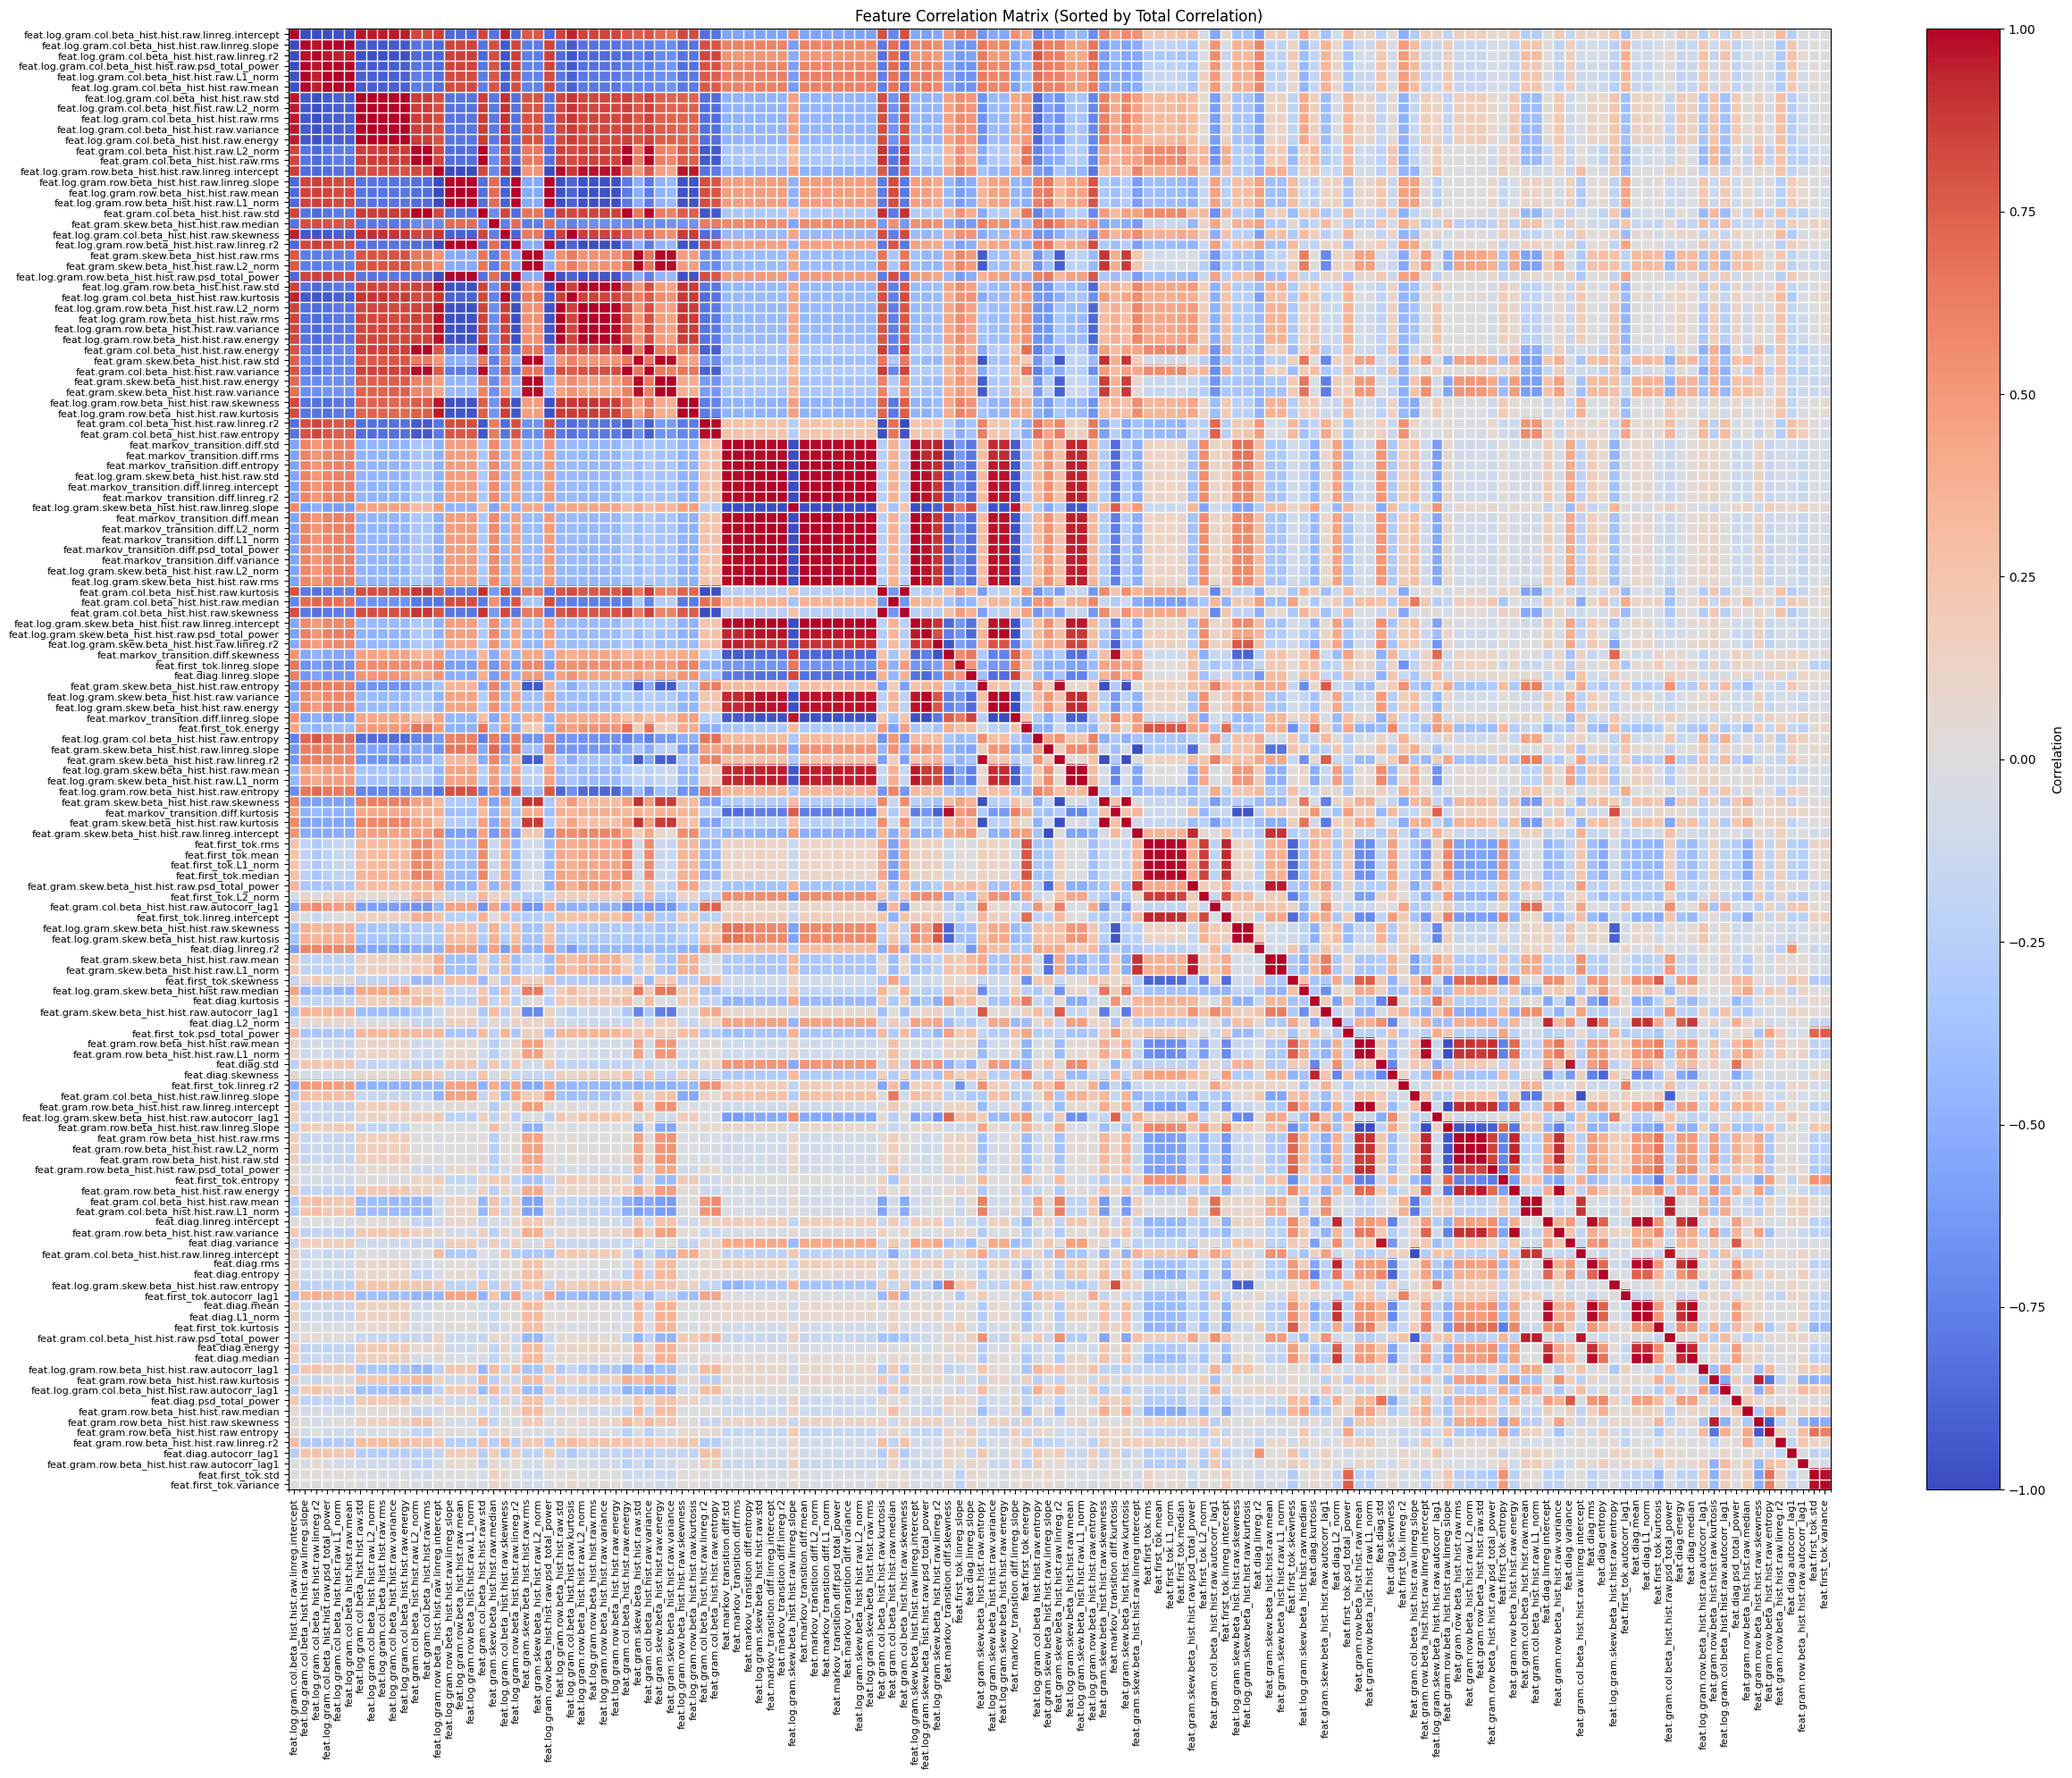

In [26]:
def plot_correlation_matrix(
	df: pl.DataFrame, feature_cols: list[str], sort_by: str = "sum"
) -> None:
	"""Plot a correlation matrix of features and identify features with NaN correlations.

	# Parameters:
	 - `df : pl.DataFrame`
	    Input dataframe containing features
	 - `feature_cols : list[str]`
	    List of feature column names to include in correlation matrix
	 - `sort_by : str`
	    Sorting method: "sum" (total correlation), "var" (variance),
	    "none" (original order)
	    (defaults to `"sum"`)
	"""
	# Calculate correlation matrix
	corr_df: pl.DataFrame = df[feature_cols].corr()
	corr_mat: np.ndarray = corr_df.to_numpy()
	dbg_tensor(corr_mat)  # Keep the original debugging call

	# Sort features if requested
	if sort_by != "none":
		# Replace NaN with 0 for sorting purposes
		corr_mat_no_nan = np.nan_to_num(corr_mat, nan=0)

		if sort_by == "sum":
			# Sort by absolute sum of correlations (total influence)
			sort_metrics = np.abs(corr_mat_no_nan).sum(axis=1)
		elif sort_by == "var":
			# Sort by variance of correlations
			sort_metrics = np.nanvar(corr_mat, axis=1)
		else:
			raise ValueError(f"Unknown sorting method: {sort_by}")

		# Get sorting indices (descending order)
		sort_idx = np.argsort(-sort_metrics)

		# Reorder matrix and feature names
		corr_mat = corr_mat[sort_idx][:, sort_idx]
		feature_cols = [feature_cols[i] for i in sort_idx]

	# Plot with larger figure size
	fig: plt.Figure = plt.figure(figsize=(25, 20))
	ax: plt.Axes = fig.add_subplot(111)
	cax: plt.AxesImage = ax.imshow(
		corr_mat, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1
	)

	# Add colorbar
	cbar = plt.colorbar(cax)
	cbar.set_label("Correlation")

	# Add feature labels
	ax.set_xticks(np.arange(len(feature_cols)))
	ax.set_yticks(np.arange(len(feature_cols)))
	ax.set_xticklabels(feature_cols, rotation=90)
	ax.set_yticklabels(feature_cols)

	# Adjust tick parameters for better readability
	plt.setp(ax.get_xticklabels(), fontsize=8)
	plt.setp(ax.get_yticklabels(), fontsize=8)

	# Add grid lines
	ax.set_xticks(np.arange(-0.5, len(feature_cols), 1), minor=True)
	ax.set_yticks(np.arange(-0.5, len(feature_cols), 1), minor=True)
	ax.grid(which="minor", color="w", linestyle="-", linewidth=1)

	# Set title
	sort_method = {
		"sum": "Total Correlation",
		"var": "Correlation Variance",
		"none": "Original Order",
	}
	ax.set_title(
		f"Feature Correlation Matrix (Sorted by {sort_method.get(sort_by, sort_by)})"
	)

	plt.tight_layout()
	plt.show()


# Pick feature columns
FEATURE_COLS: list[str] = [
	col for col in DATA_FILTERED.columns if col.startswith("feat.")
]

# Plot correlation matrix
plot_correlation_matrix(DATA_FILTERED, FEATURE_COLS)

In [27]:
DATA_SCALED: pl.DataFrame = DATA_FILTERED.with_columns(
	[
		((pl.col(col) - pl.col(col).mean()) / pl.col(col).std()).alias(col)
		for col in FEATURE_COLS
	]
)
DATA_SCALED

# plot_correlation_matrix(DATA_SCALED, FEATURE_COLS)

feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.log.gram.col.beta_hist.hist.raw.linreg.r2,feat.log.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.diag.rms,feat.gram.col.beta_hist.hist.raw.variance,feat.diag.entropy,feat.gram.row.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.mean,feat.gram.row.beta_hist.hist.raw.skewness,feat.gram.skew.beta_hist.hist.raw.energy,feat.log.gram.skew.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.mean,feat.log.gram.skew.beta_hist.hist.raw.mean,feat.log.gram.skew.beta_hist.hist.raw.std,feat.diag.linreg.slope,feat.diag.kurtosis,feat.first_tok.L1_norm,feat.gram.row.beta_hist.hist.raw.L2_norm,feat.markov_transition.diff.kurtosis,feat.log.gram.row.beta_hist.hist.raw.entropy,feat.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.gram.skew.beta_hist.hist.raw.L2_norm,feat.diag.autocorr_lag1,feat.gram.col.beta_hist.hist.raw.median,feat.gram.row.beta_hist.hist.raw.energy,feat.first_tok.skewness,feat.log.gram.col.beta_hist.hist.raw.linreg.intercept,feat.first_tok.psd_total_power,feat.gram.col.beta_hist.hist.raw.kurtosis,feat.diag.linreg.r2,feat.log.gram.row.beta_hist.hist.raw.energy,feat.log.gram.col.beta_hist.hist.raw.energy,feat.log.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.gram.row.beta_hist.hist.raw.linreg.slope,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.first_tok.autocorr_lag1,feat.first_tok.kurtosis,…,feat.gram.skew.beta_hist.hist.raw.rms,feat.gram.skew.beta_hist.hist.raw.skewness,feat.log.gram.col.beta_hist.hist.raw.L2_norm,feat.log.gram.col.beta_hist.hist.raw.rms,feat.diag.std,feat.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.diag.L2_norm,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.gram.col.beta_hist.hist.raw.rms,feat.gram.col.beta_hist.hist.raw.psd_total_power,feat.gram.row.beta_hist.hist.raw.std,feat.first_tok.variance,feat.gram.skew.beta_hist.hist.raw.median,feat.first_tok.L2_norm,feat.diag.L1_norm,feat.markov_transition.diff.linreg.intercept,feat.gram.col.beta_hist.hist.raw.std,feat.log.gram.col.beta_hist.hist.raw.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.linreg.slope,feat.log.gram.skew.beta_hist.hist.raw.entropy,feat.log.gram.row.beta_hist.hist.raw.std,feat.log.gram.skew.beta_hist.hist.raw.variance,feat.log.gram.row.beta_hist.hist.raw.linreg.slope,feat.diag.variance,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.log.gram.col.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.rms,feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.skew.beta_hist.hist.raw.std,feat.markov_transition.diff.std,activation.cls,feat.first_tok.linreg.r2,feat.gram.col.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.entropy,feat.first_tok.entropy,feat.markov_transition.diff.mean,feat.markov_transition.diff.rms
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64
-0.337689,-0.863237,-0.159618,0.442892,0.902994,0.963007,-0.288697,-0.7244,-1.254955,0.964072,-0.008704,-0.692114,-0.008704,-0.277801,0.514015,-1.266912,0.24403,-0.32214,-0.057261,-0.682661,-0.252545,0.992118,-0.451801,-0.552569,-0.238897,-0.631021,0.814896,0.489934,0.796153,-0.986983,0.862457,0.989938,-1.580293,0.279448,0.493229,-1.946191,-0.375439,…,0.992118,1.141701,0.970525,0.970525,1.713928,-0.485985,0.28935,-0.687398,0.870882,-0.465602,-0.340838,0.776566,-0.494563,0.104872,0.204746,-0.263758,0.878836,-0.780488,-0.82196,-0.339936,0.836533,-0.313089,-0.724653,1.435507,0.175968,-0.818746,0.839435,-0.283626,1.023283,-0.21145,"""gemma-2b:L0:H0""",-0.77165,-0.688287,-1.127713,0.604305,-0.266285,-0.21145
-0.797421,-0.926592,-0.228651,-0.394176,1.507823,-0.396461,0.343294,-0.7244,-0.22357,1.821513,-0.152863,-1.049617,-0.152863,-0.271836,0.417502,0.400592,0.069341,0.05645,-0.057261,-0.682661,-0.447071,1.636253,-0

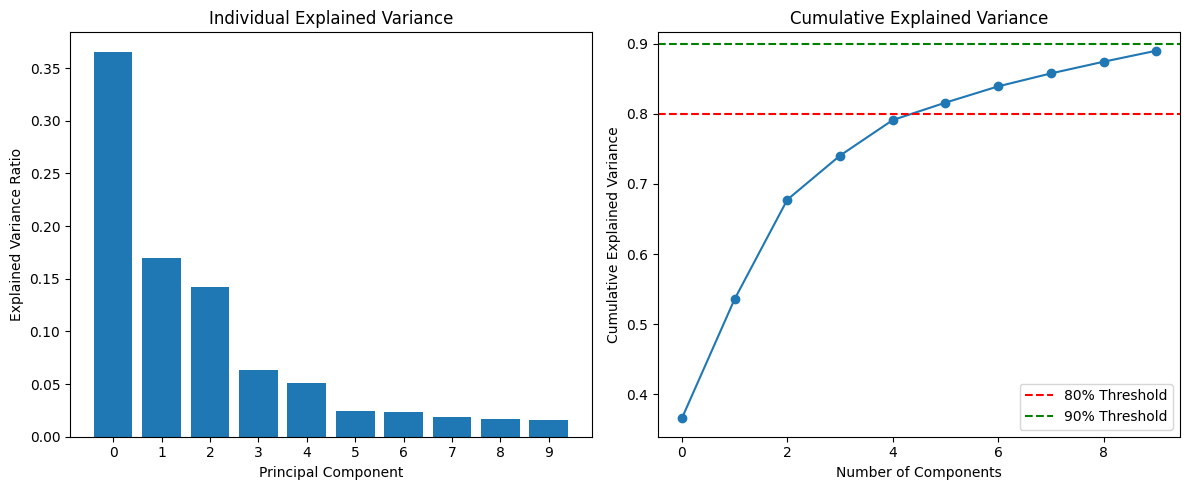

Number of components: 10
Total explained variance: 0.8901
Components needed for 80% variance: 6
Components needed for 90% variance: 1


In [28]:
def apply_pca(
    data: pl.DataFrame, 
    n_components: int, 
    feature_cols: list[str],
    plot_variance: bool = True
) -> tuple[np.ndarray, PCA]:
    """Compute PCA and optionally plot explained variance.
    
    # Parameters:
     - `data : pl.DataFrame`
        Input dataframe
     - `n_components : int`
        Number of PCA components to compute
     - `feature_cols : list[str]`
        Feature columns to use for PCA
     - `plot_variance : bool`
        Whether to plot explained variance (defaults to `True`)
    
    # Returns:
     - `tuple[np.ndarray, PCA]` 
        Tuple containing:
        - Transformed data array
        - Fitted PCA object
    """
    # Fit PCA
    pca: PCA = PCA(n_components=n_components, random_state=0)
    reduced: np.ndarray = pca.fit_transform(data[feature_cols].to_numpy())
    
    # Plot explained variance if requested
    if plot_variance:
        # Calculate explained variance
        explained_variance = pca.explained_variance_ratio_
        cumulative_variance = np.cumsum(explained_variance)
        
        # Create figure with two subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # Plot individual explained variance
        ax1.bar(range(len(explained_variance)), explained_variance)
        ax1.set_xlabel('Principal Component')
        ax1.set_ylabel('Explained Variance Ratio')
        ax1.set_title('Individual Explained Variance')
        ax1.set_xticks(range(min(10, len(explained_variance))))
        
        # Plot cumulative explained variance
        ax2.plot(range(len(cumulative_variance)), cumulative_variance, 'o-')
        ax2.axhline(y=0.8, color='r', linestyle='--', label='80% Threshold')
        ax2.axhline(y=0.9, color='g', linestyle='--', label='90% Threshold')
        ax2.set_xlabel('Number of Components')
        ax2.set_ylabel('Cumulative Explained Variance')
        ax2.set_title('Cumulative Explained Variance')
        ax2.set_xticks(range(0, min(20, len(cumulative_variance)), 2))
        ax2.legend()
        
        plt.tight_layout()
        plt.show()
        
        # Print summary
        print(f"Number of components: {n_components}")
        print(f"Total explained variance: {cumulative_variance[-1]:.4f}")
        
        # Find number of components for 80% and 90% variance
        comp_80 = np.argmax(cumulative_variance >= 0.8) + 1
        comp_90 = np.argmax(cumulative_variance >= 0.9) + 1
        print(f"Components needed for 80% variance: {comp_80}")
        print(f"Components needed for 90% variance: {comp_90}")
    
    return reduced, pca

# PCA
pca_data: np.ndarray
pca_obj: PCA
pca_data, pca_obj = apply_pca(DATA_SCALED, n_components=10, feature_cols=FEATURE_COLS)

/tmp/ipykernel_33648/193493886.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10" if len(unique_labels) <= 20 else "Set3")


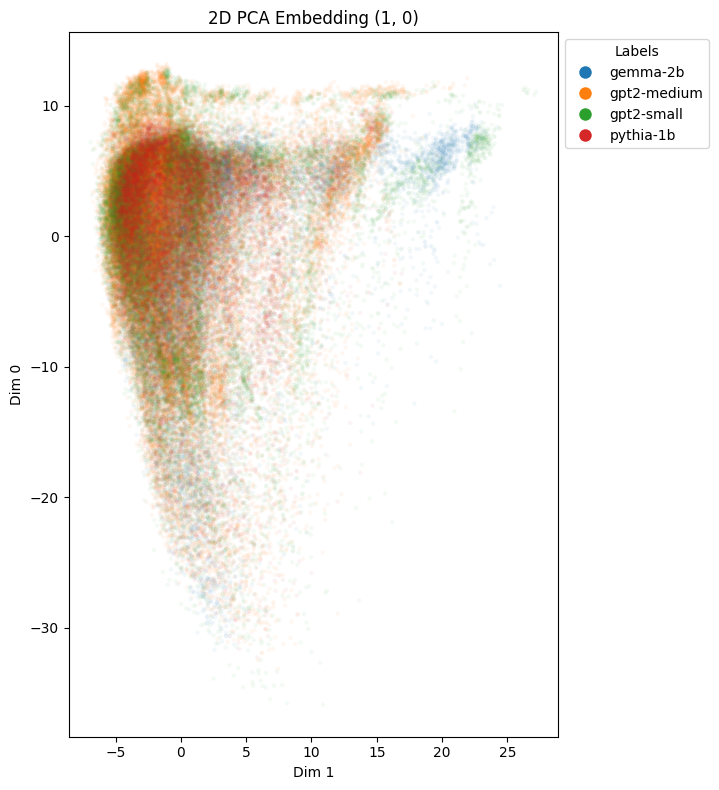

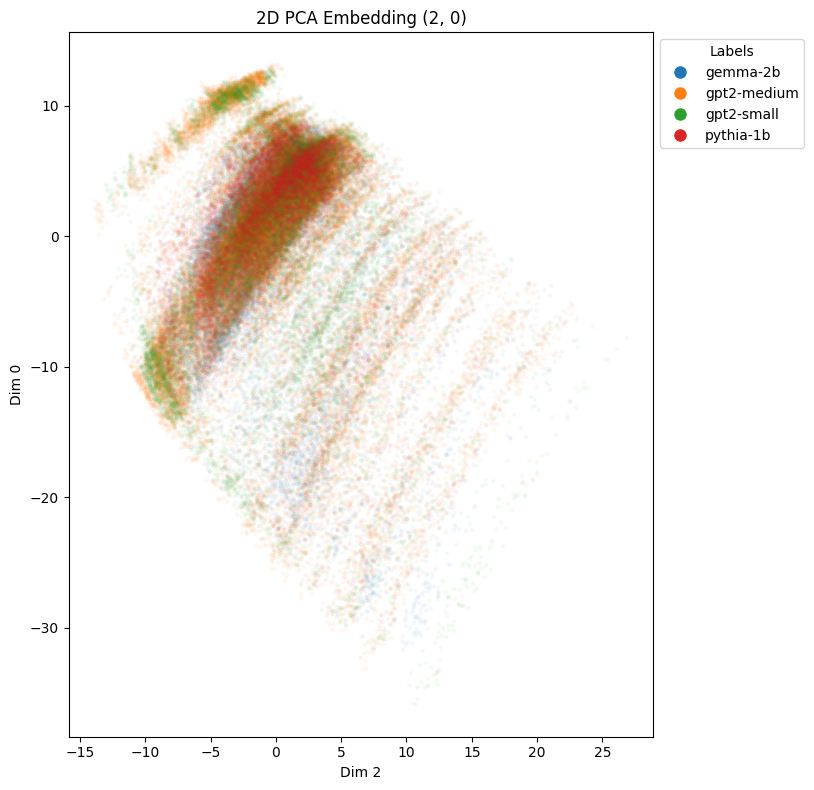

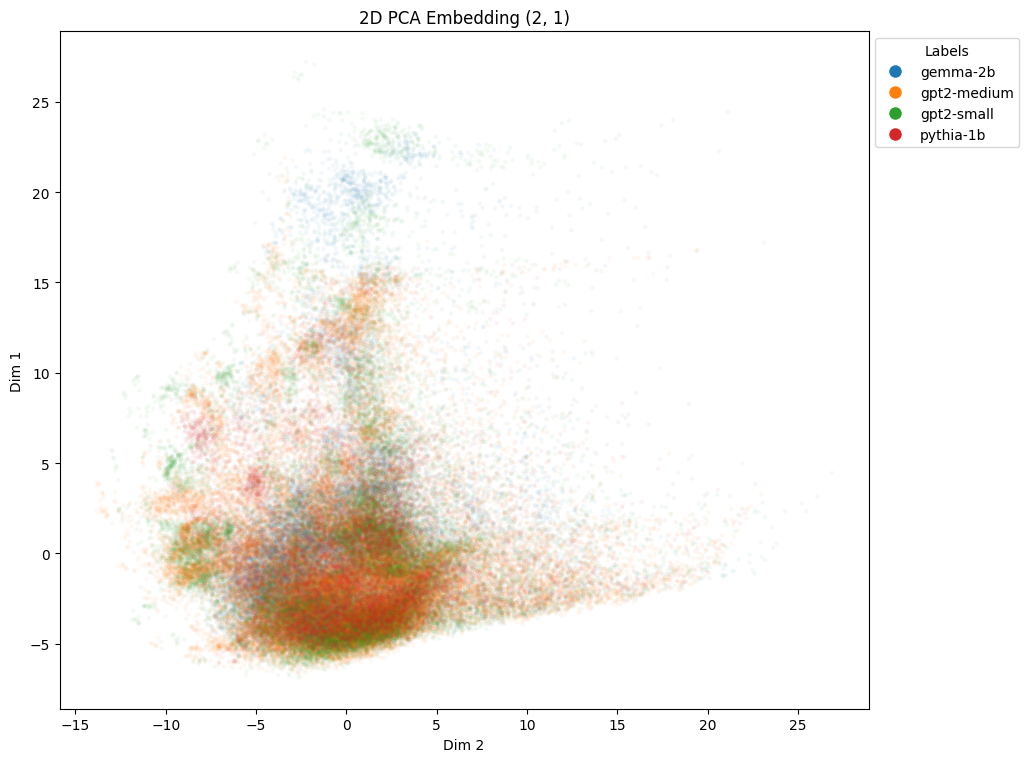

In [53]:
def plot_embedding(
    embedding: np.ndarray, 
    labels: pl.Series, 
    dims: tuple[int, int] = (0, 1),
    title: str = "2D PCA Embedding",
    alpha: float = 0.9,
    marker_size: int = 1,
) -> None:
    """Scatter plot of 2D embedding with points colored by label.

    # Parameters:
     - `embedding : np.ndarray`
        2D embedding array with shape (n_samples, 2)
     - `labels : pl.Series`
        Labels for each point
     - `dims : tuple[int, int]`
        Dimensions to plot (defaults to (0, 1))
     - `title : str`
        Plot title (defaults to "2D PCA Embedding")
    """
    fig: plt.Figure = plt.figure(figsize=(10, 8))
    ax: plt.Axes = fig.add_subplot(111)

    # Convert labels to numpy array
    label_values = labels.to_numpy()

    # Get unique labels for coloring
    unique_labels = np.unique(label_values)

    # Create colormap with enough colors
    cmap = plt.cm.get_cmap("tab10" if len(unique_labels) <= 20 else "Set3")

    # Store handles for legend
    handles = []
    
    # Plot each label group with a different color
    for i, label in enumerate(unique_labels):
        mask = label_values == label
        color = cmap(i)
        
        # Main scatter plot (small points)
        ax.scatter(
            embedding[mask, dims[0]],
            embedding[mask, dims[1]],
            c=[color],
            alpha=alpha,
            s=marker_size,
            edgecolors="none",
        )
        
        # Create a separate point for the legend (not displayed in the plot)
        handle = plt.Line2D(
            [0], [0],
            marker='o', 
            color='w', 
            markerfacecolor=color,
            markersize=10,  # Big marker size for legend
            label=str(label)
        )
        handles.append(handle)

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlabel(f"Dim {dims[0]}")
    ax.set_ylabel(f"Dim {dims[1]}")
    
    # Create legend with large dots
    legend = plt.legend(
        handles=handles,
        loc="upper left",
        bbox_to_anchor=(1, 1), 
        title="Labels",
    )
        
    plt.tight_layout()
    plt.show()



for i in range(1, 3):
    for j in range(0, i):
        plot_embedding(
            pca_data,
            DATA_SCALED["activation.model"],
            (i, j),
            alpha=0.05,
            marker_size=10,
            title=f"2D PCA Embedding ({i}, {j})",
        )

In [60]:
def plot_embedding_3d_interactive(
    embedding: np.ndarray, 
    labels: pl.Series, 
    dims: tuple[int, int, int] = (0, 1, 2),
    title: str = "3D PCA Embedding",
    alpha: float = 0.8,
    marker_size: int = 5,
) -> None:
    """Create an interactive 3D scatter plot of embedding that can be rotated.
    
    # Parameters:
     - `embedding : np.ndarray`
        Embedding array with shape (n_samples, n_components)
     - `labels : pl.Series`
        Labels for each point
     - `dims : tuple[int, int, int]`
        Dimensions to plot (defaults to (0, 1, 2))
     - `title : str`
        Plot title (defaults to "3D PCA Embedding")
     - `alpha : float`
        Transparency of points (defaults to 0.8)
     - `marker_size : int`
        Size of markers (defaults to 5)
    """

    
    # Convert embedding dimensions to DataFrame
    plot_df = pd.DataFrame({
        'x': embedding[:, dims[0]],
        'y': embedding[:, dims[1]],
        'z': embedding[:, dims[2]],
        'label': labels.to_numpy()
    })
    
    # Create interactive 3D scatter plot
    fig = px.scatter_3d(
        plot_df, 
        x='x', 
        y='y', 
        z='z',
        color='label',
        opacity=alpha,
        size_max=marker_size,
        # no border around points
        title=title,
        labels={
            'x': f'Dimension {dims[0]}',
            'y': f'Dimension {dims[1]}',
            'z': f'Dimension {dims[2]}',
            'label': 'Label'
        },
    )

    # Remove marker borders
    fig.update_traces(marker=dict(
        size=marker_size,
        line=dict(width=0, color='rgba(0,0,0,0)')
    ))
    
    # Update layout for better appearance
    fig.update_layout(
        title={
            'text': title,
            'y': 0.95,
            'x': 0.5,
            'xanchor': 'center',
            'yanchor': 'top'
        },
        legend=dict(
            itemsizing='constant',
            title_text='Labels',
            bgcolor='rgba(255, 255, 255, 0.8)'
        ),
        scene=dict(
            xaxis_title=f'Dimension {dims[0]}',
            yaxis_title=f'Dimension {dims[1]}',
            zaxis_title=f'Dimension {dims[2]}',
        )
    )
    
    # Display the plot
    fig.show()

plot_embedding_3d_interactive(
    pca_data,
    DATA_SCALED["activation.model"],
    dims=(0, 1, 2),
    title="Interactive 3D PCA Embedding",
    alpha=0.1,
    marker_size=1,
)

/tmp/ipykernel_33648/3321039835.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20" if len(unique_labels) <= 20 else "tab20b")
/tmp/ipykernel_33648/3321039835.py:88: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Labels", loc="upper left", bbox_to_anchor=(1, 1))


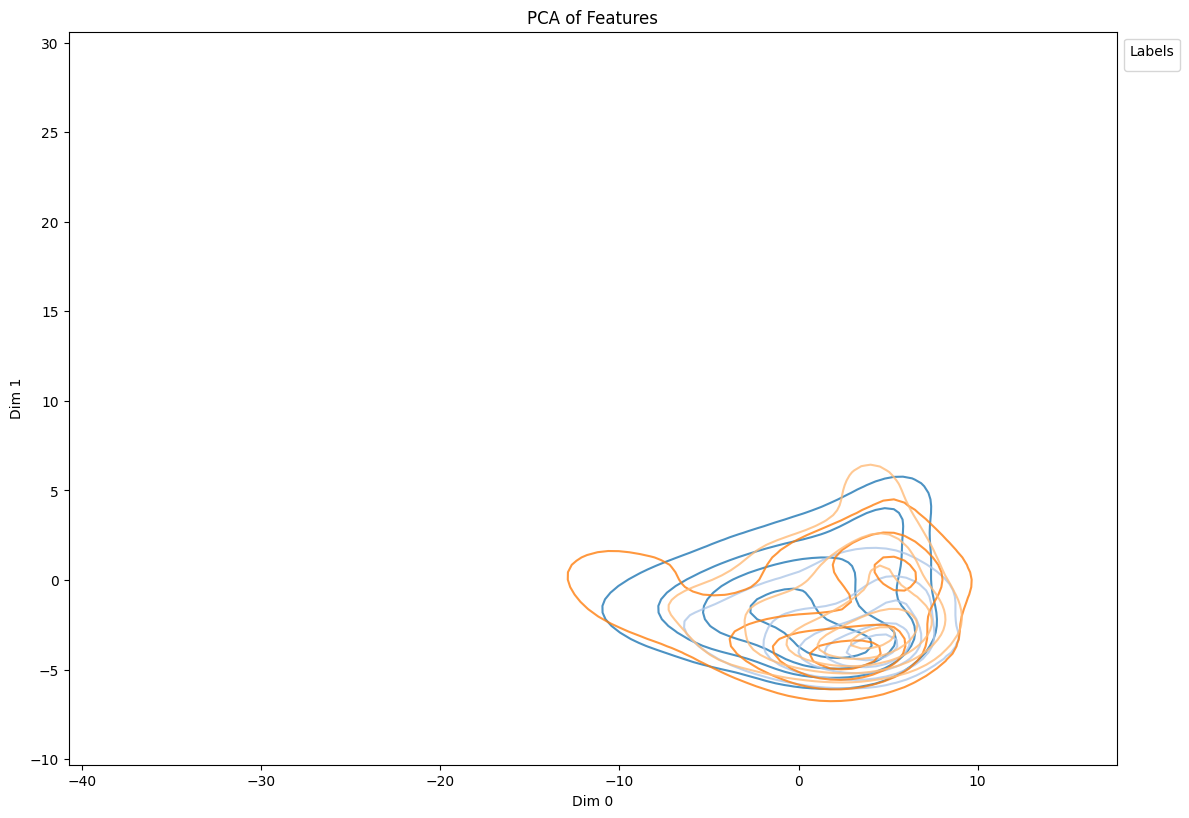

In [30]:
def plot_embedding_kde(embedding: np.ndarray, labels: pl.Series, title: str) -> None:
	"""Scatter plot of 2D embedding with KDE contours colored by label.

	# Parameters:
	 - `embedding : np.ndarray`
	    2D embedding array with shape (n_samples, 2)
	 - `labels : pl.Series`
	    Labels for each point
	 - `title : str`
	    Plot title
	"""
	import scipy.stats as stats

	fig: plt.Figure = plt.figure(figsize=(12, 10))
	ax: plt.Axes = fig.add_subplot(111)

	# Convert labels to numpy array
	label_values = labels.to_numpy()

	# Get unique labels for coloring
	unique_labels = np.unique(label_values)

	# Create colormap with enough colors
	cmap = plt.cm.get_cmap("tab20" if len(unique_labels) <= 20 else "tab20b")

	# Sample a subset of points for scatter plot (optional)
	sample_size = min(5000, embedding.shape[0])
	sample_indices = np.random.choice(embedding.shape[0], sample_size, replace=False)

	# Plot KDE contours for each label group
	for i, label in enumerate(unique_labels):
		mask = label_values == label
		points = embedding[mask]

		if len(points) > 50:  # Only compute KDE if enough points
			# Perform KDE
			try:
				# Create grid for KDE evaluation
				x_min, x_max = points[:, 0].min(), points[:, 0].max()
				y_min, y_max = points[:, 1].min(), points[:, 1].max()

				# Add some padding
				x_range = x_max - x_min
				y_range = y_max - y_min
				x_min -= 0.1 * x_range
				x_max += 0.1 * x_range
				y_min -= 0.1 * y_range
				y_max += 0.1 * y_range

				# Create grid
				xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
				positions = np.vstack([xx.ravel(), yy.ravel()])

				# Compute kernel density
				kde = stats.gaussian_kde(points.T, bw_method="scott")
				f = kde(positions)
				f = f.reshape(xx.shape)

				# Plot contours
				color = cmap(i)
				contour = ax.contour(
					xx, yy, f, levels=5, colors=[color], alpha=0.8, linewidths=1.5
				)
				contourf = ax.contourf(
					xx,
					yy,
					f,
					levels=8,
					colors=[color + (a,) for a in np.linspace(0.05, 0.3, 8)],
					antialiased=True,
				)

				# Add a label marker for the legend
				ax.plot([], [], color=color, label=str(label), linewidth=2)

			except Exception as e:
				# Fall back to scatter if KDE fails
				# ax.scatter(points[:, 0], points[:, 1],
				#           c=[cmap(i)], label=str(label), alpha=0.1, s=10, edgecolors='none')
				pass
		else:
			# Not enough points for KDE, use scatter
			# ax.scatter(points[:, 0], points[:, 1],
			#           c=[cmap(i)], label=str(label), alpha=0.2, s=10, edgecolors='none')
			pass

	# Add legend
	ax.legend(title="Labels", loc="upper left", bbox_to_anchor=(1, 1))

	ax.set_title(title)
	ax.set_aspect("equal")
	ax.set_xlabel("Dim 0")
	ax.set_ylabel("Dim 1")

	plt.tight_layout()
	plt.show()


plot_embedding_kde(pca_data[:, :2], DATA_SCALED["activation.model"], "PCA of Features")

In [31]:
def apply_tsne(
	data: pl.DataFrame, n_components: int = 2, perplexity: float = 30.0
) -> np.ndarray:
	"""Compute t-SNE."""
	tsne: TSNE = TSNE(n_components=n_components, perplexity=perplexity, random_state=0)
	embedded: np.ndarray = tsne.fit_transform(data)
	return embedded


def cluster_kmeans(data: np.ndarray, n_clusters: int) -> np.ndarray:
	"""Cluster with K-Means."""
	kmeans: KMeans = KMeans(n_clusters=n_clusters, random_state=0)
	labels: np.ndarray = kmeans.fit_predict(data)
	return labels


def plot_embedding(embedding: np.ndarray, labels: pl.Series, title: str) -> None:
	"""Scatter plot of 2D embedding with label text."""
	fig: plt.Figure = plt.figure()
	ax: plt.Axes = fig.add_subplot(111)
	sc: plt.PathCollection = ax.scatter(embedding[:, 0], embedding[:, 1])
	ax.set_title(title)
	ax.set_aspect("equal")
	ax.set_xlabel("Dim 1")
	ax.set_ylabel("Dim 2")
	# Optionally, overlay text for each point
	# for i, lbl in enumerate(labels):
	#     ax.text(embedding[i, 0], embedding[i, 1], lbl, fontsize=6)
	plt.show()


def main_example(df: pl.DataFrame) -> None:
	# t-SNE
	tsne_data: np.ndarray = apply_tsne(df)

	# Clustering
	kmeans_labels: np.ndarray = cluster_kmeans(tsne_data, n_clusters=5)

	# Plot PCA embedding
	# (using first two PCA components for a 2D plot)
	plot_embedding(pca_data[:, :2], df["activation.cls"], "PCA of Features")

	# Plot t-SNE embedding
	plot_embedding(tsne_data, df["activation.cls"], "t-SNE of Features")

	# Plot the clusters on t-SNE
	# (If you prefer numeric cluster labels, you can cast them to string.)
	cluster_series: pl.Series = pl.Series(kmeans_labels, index=df.index, dtype=str)
	plot_embedding(tsne_data, cluster_series, "K-Means Clusters (t-SNE)")


# main_example(DATA_NANLESS)